# Assignment 2: Predicates and Sets

*If something in assignment is unclear or does not make sense, make a note and ask the lecturer, a TA in the exercise session, or a friend!*

### Homework Exercises

Solutions to the following exercises are to be handed in, either typed or handwritten. Write neatly and concisely, so the solutions are easy to read. You are allowed (even encouraged) to work in groups, but solutions have to be written and handed in individually. If you worked in groups, please state on your answer sheet who you worked with. 

1. Express each of the following predicates and propositions in formal predicate logic notation. The domain is the natural numbers $\mathbb{N}$. You may define predicates involving logical symbols ($\land$, $\lor$, $\neg$, $\to$, $\forall$, $\exists$), but also the arithmetic symbols $+$, $\cdot$, $=$ and any integer constants $0, 1, \dots$. You may *not* use exponentiation symbols, $x^y$. For example, the predicate "$n$ is an even number" could be defined as $\operatorname{Even}(n) := \exists m. (2m = n)$ or as $\operatorname{Even}'(n) := \exists m. (m + m = n)$.

    * $m$ is a divisor of $n$.
    * $n$ is a prime number.
    * $n$ is a power of a prime. (This one is a bit tricky!)
        
2. Prove De Morgan's law for set equality, which states that for all sets $A$ and $B$,
$$
\overline{A \cap B} = \overline{A} \cup \overline{B}.
$$ 
Do so by providing a chain of if and only ifs that an element $x$ is contained in the left hand-side of the equation above if and only if $x$ is contained in the right hand-side. You may use the propositional version of De Morgan's law in equation 3.11 in MIT, stating that for propositions $p$ and $q$, $\neg (p \land q) \equiv \neg p \lor \neg q$.
   
3. A predicate formula is in *prenex form* when all its quantifiers come at the beginning. For example, 
$$ \forall x \exists y \forall z \exists w (P(x, w) \land (Q(x, y) \lor R(z))) $$
is in prenex form.

It turns out that every predicate logic formula can be rewritten in prenex form following these steps. In order to do this, use De Morgan's laws to push negations into the formula: $\neg \forall x. P(x)$ becomes $\exists x. \neg P(x)$, and vice versa. When doing this, read the formulas out loud to make sure the transformation make sense to you.

With this in mind, write the following predicate formula in prenex form: 

$$\neg (\forall x. \exists y. P(x) \land Q(x, y)) \lor   (  (\exists x. R(x, y))  \lor \exists z. \forall x. (S(z) \land T(x) ) ).$$

Hint: Look out for free and bound variables!

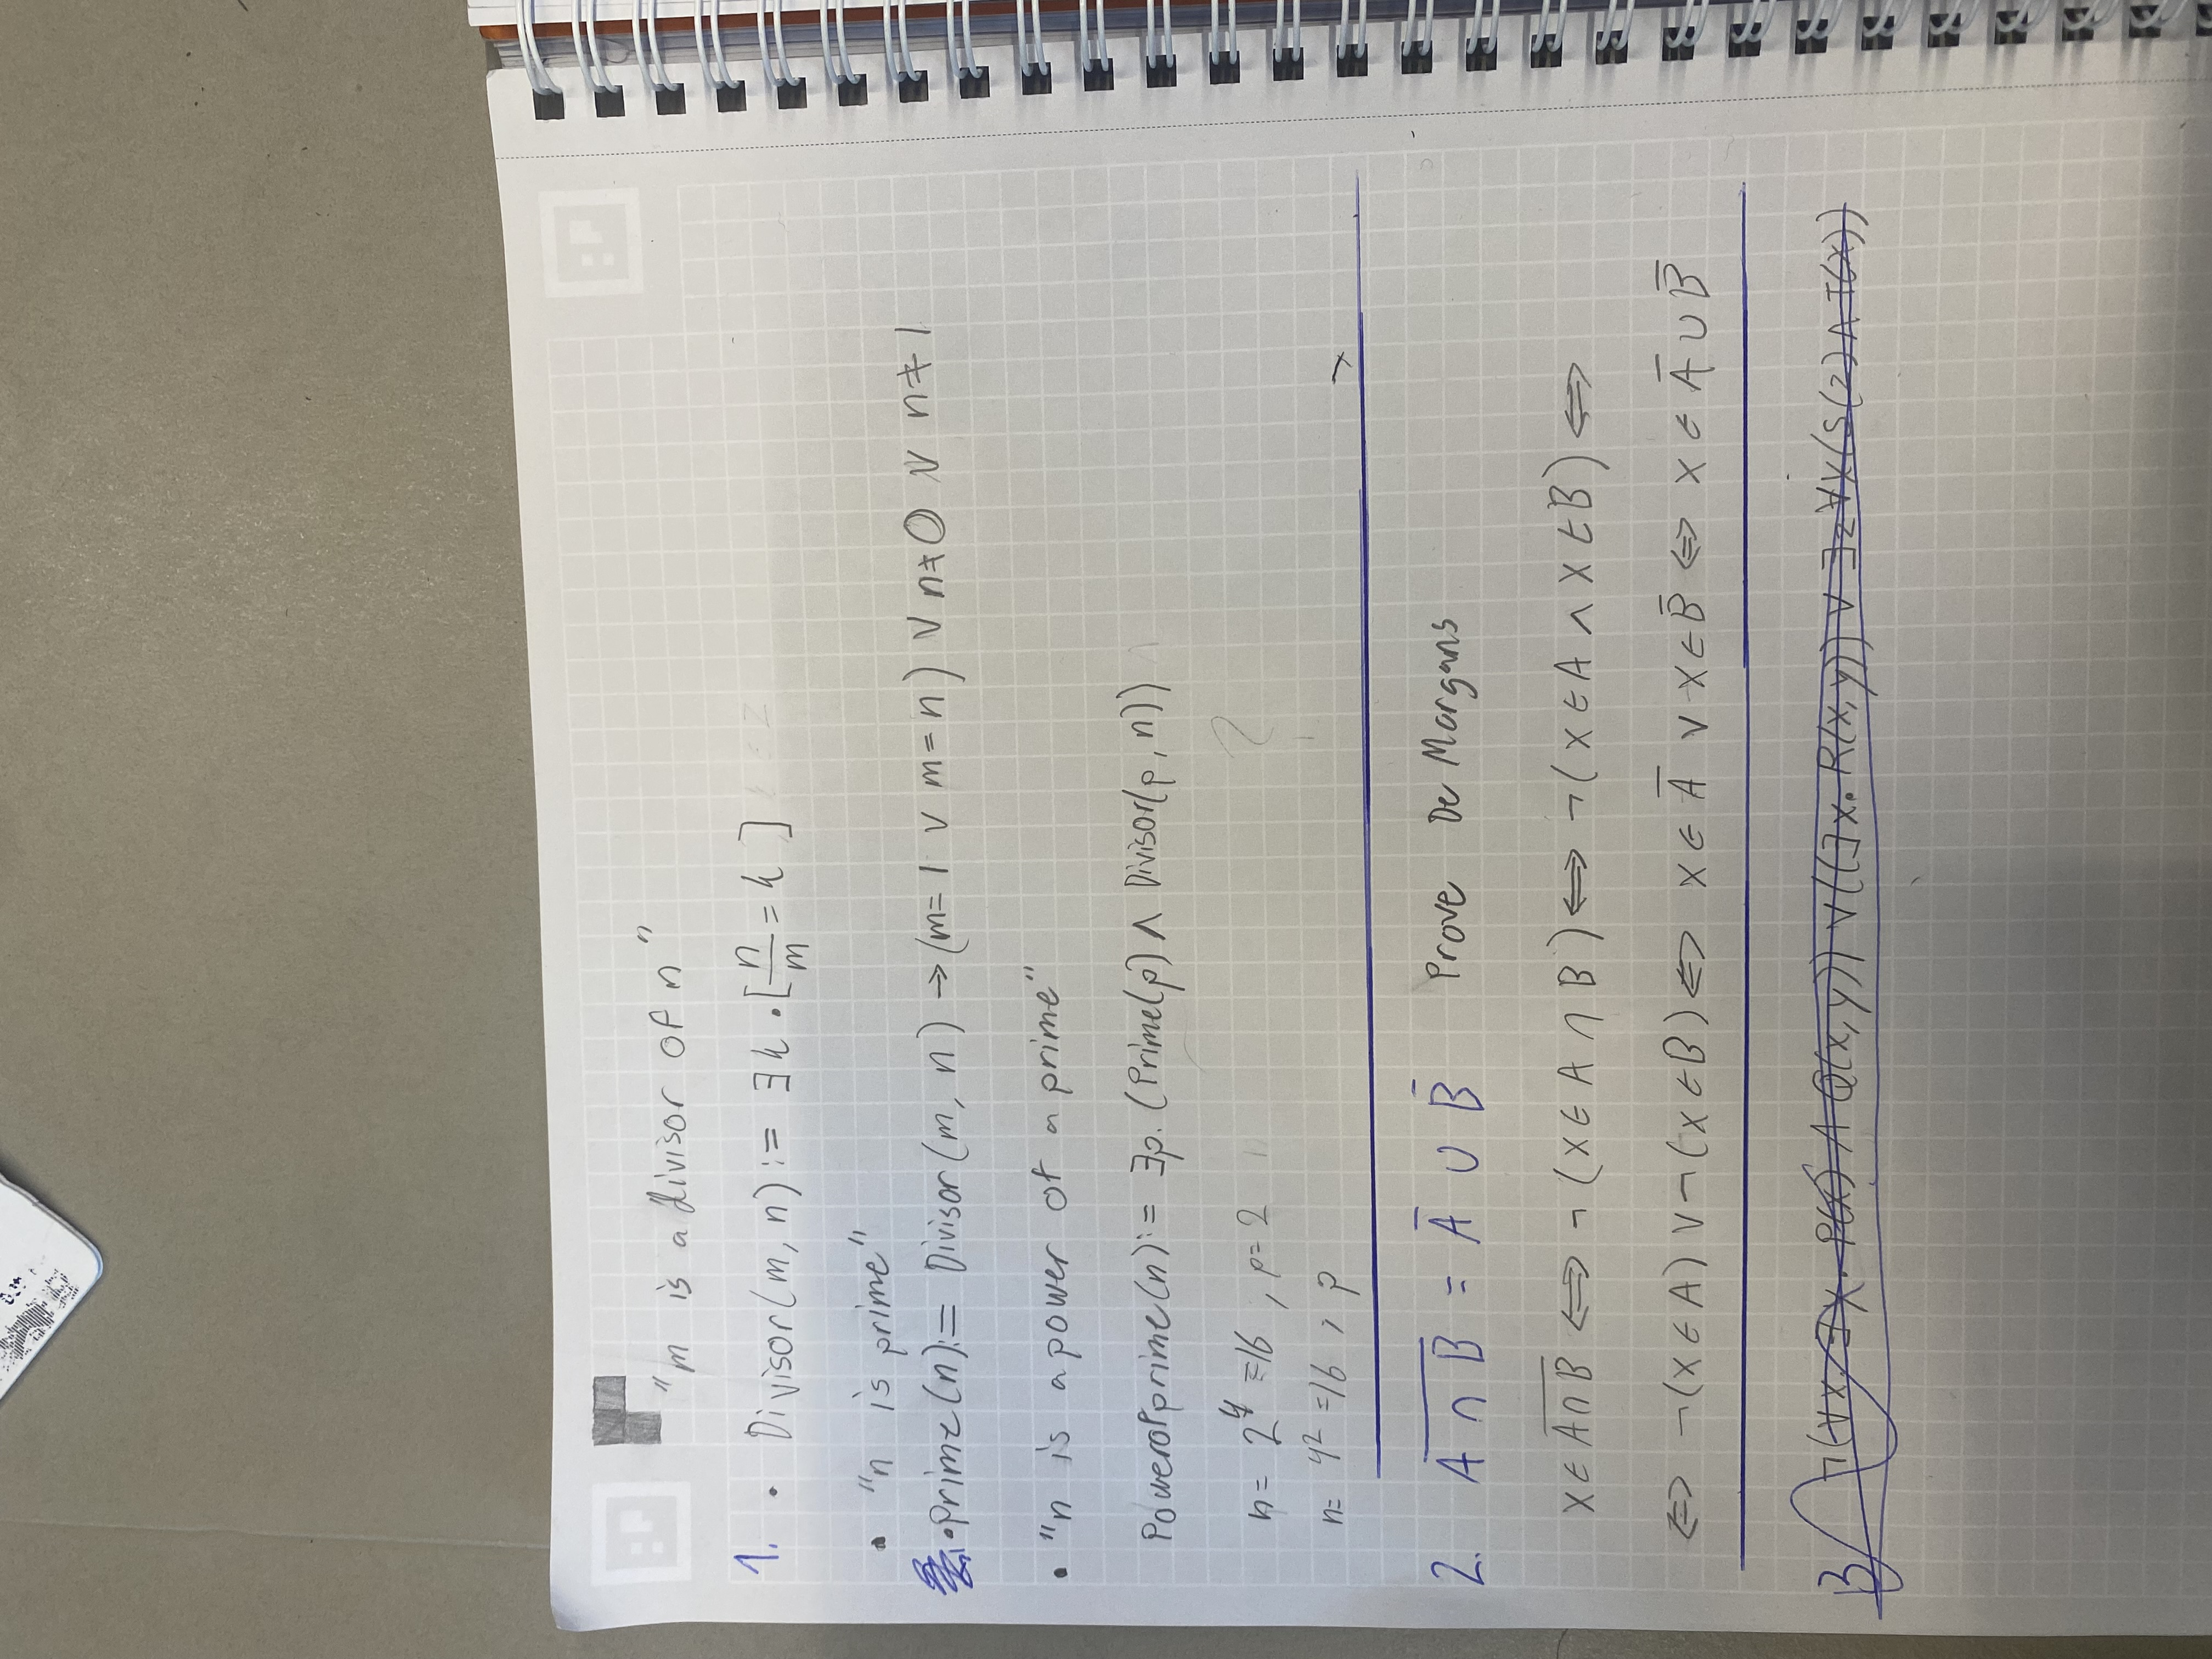

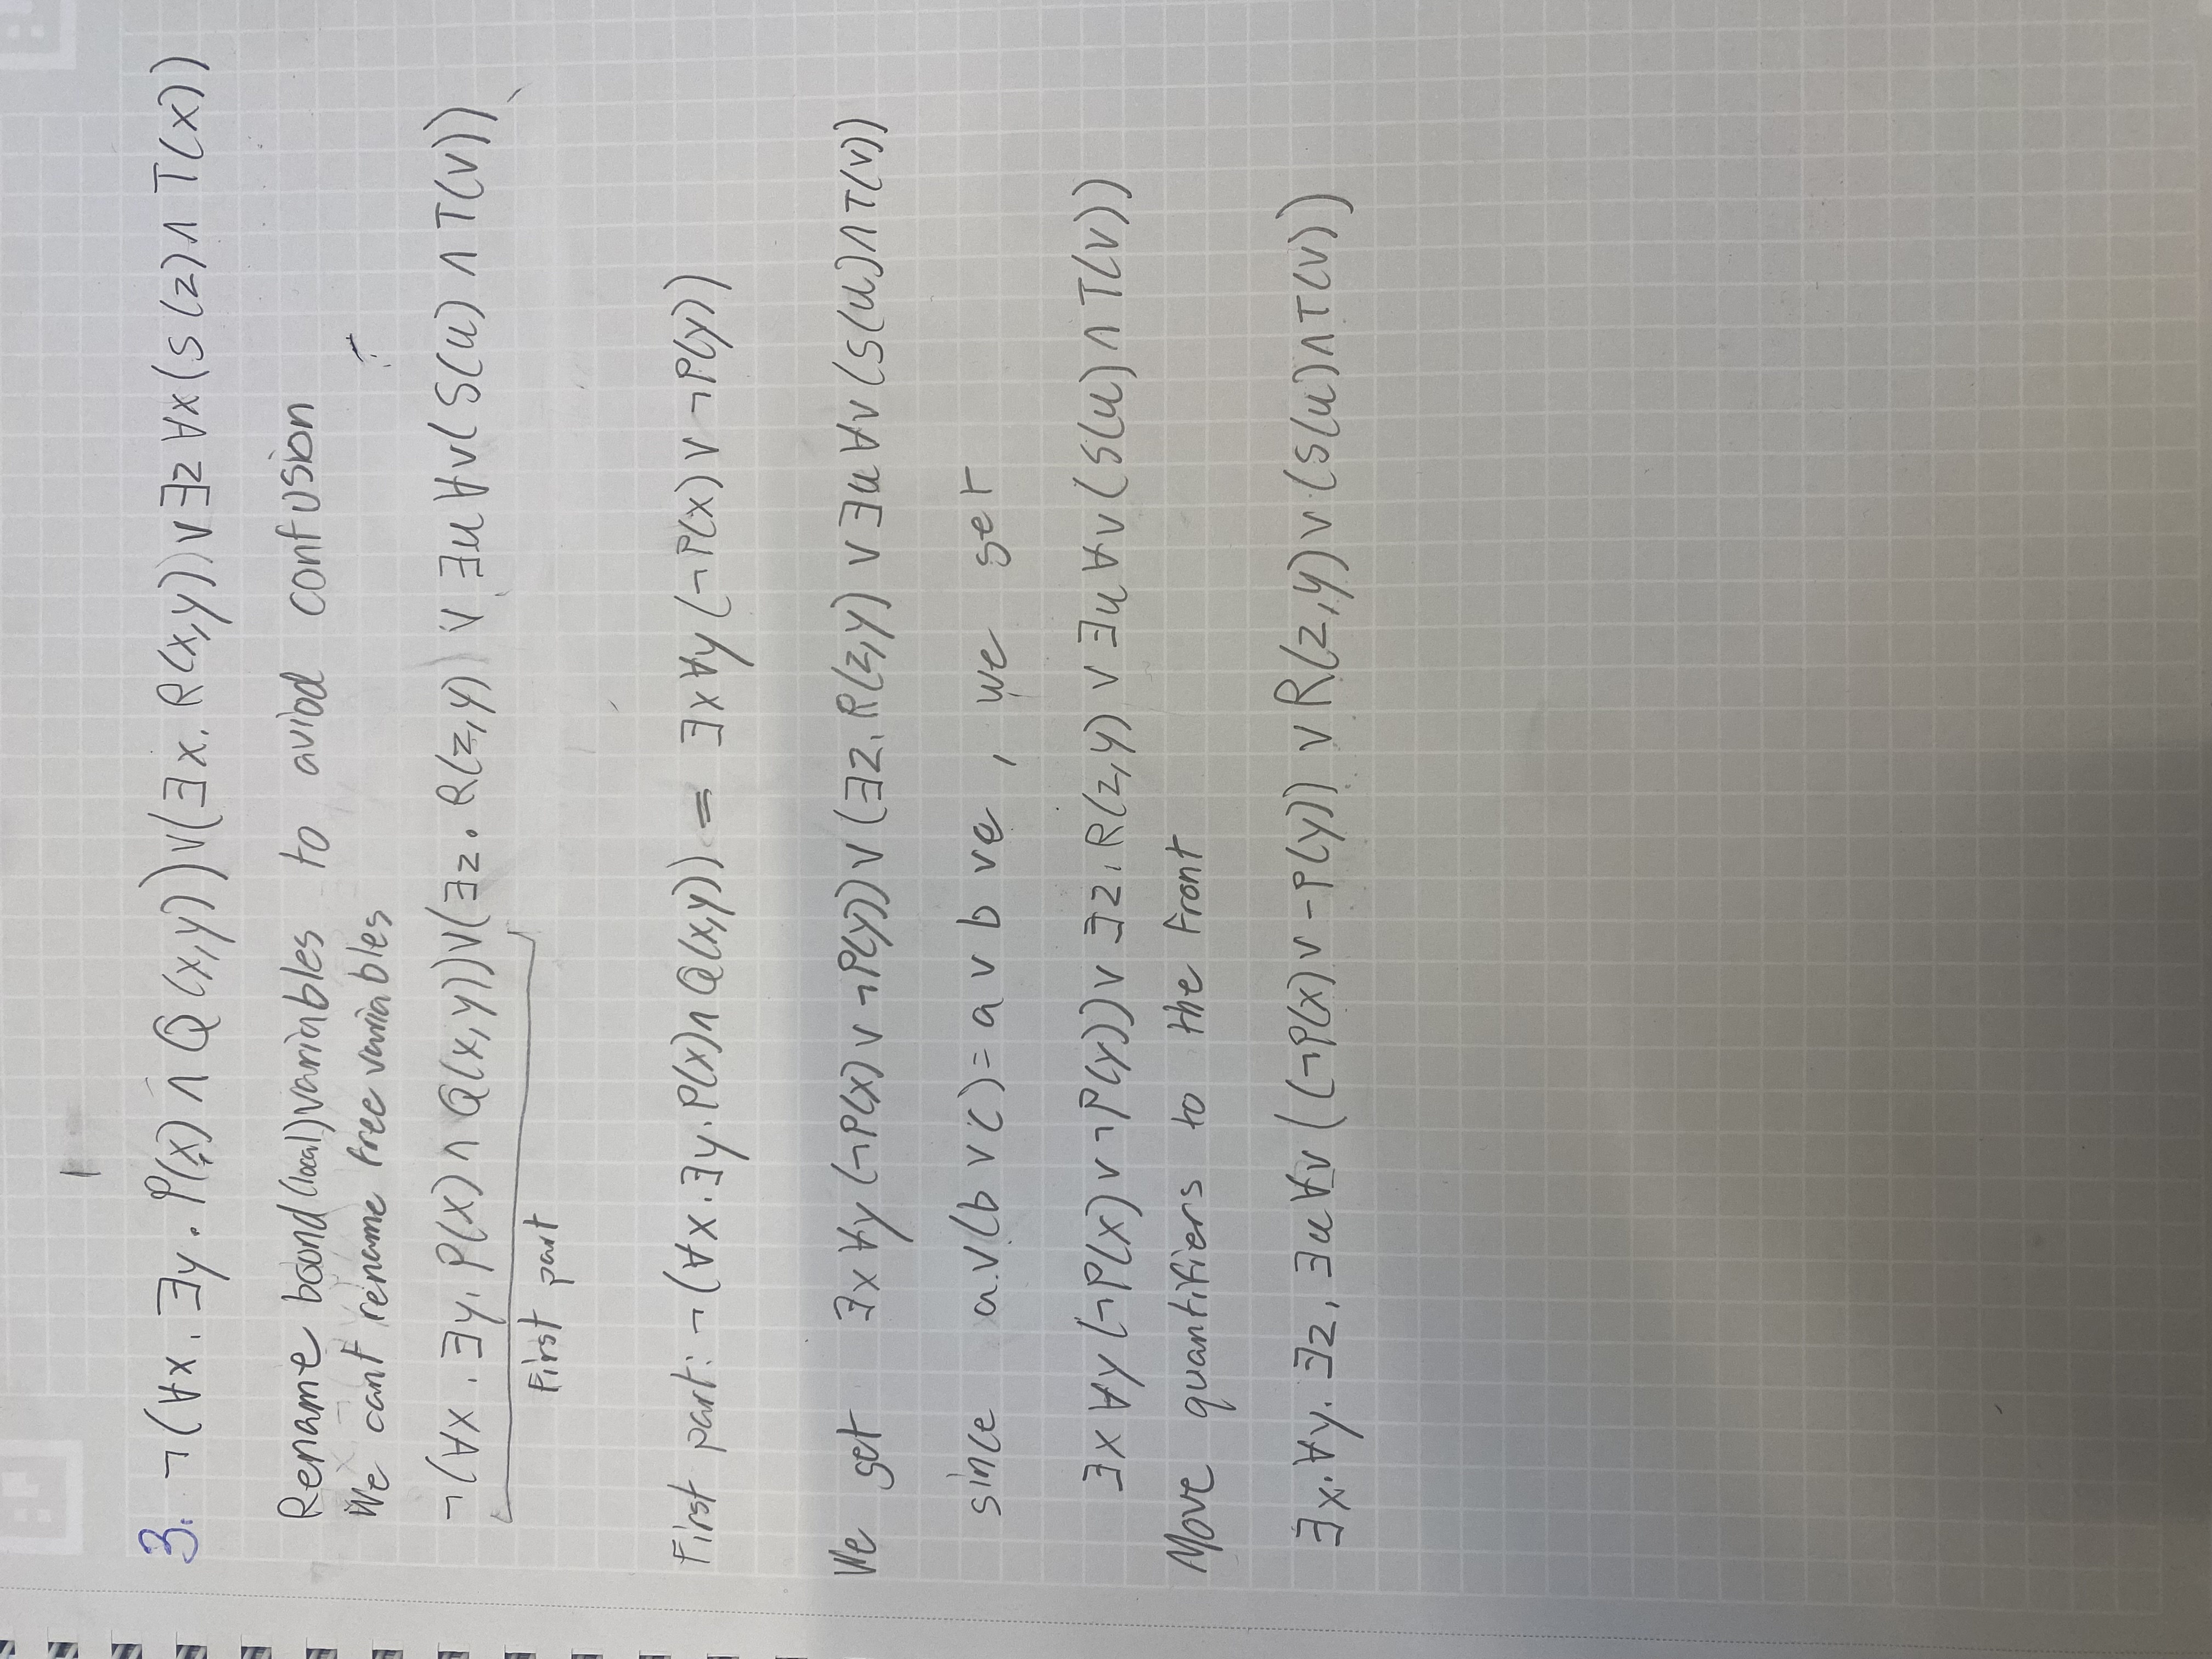

In [43]:
from IPython.display import Image, display

display(Image(filename='IMG_6257.jpeg'))
display(Image(filename='IMG_6256.jpeg'))

### Programming Exercise
In this exercise you will design a Python function that takes a set $S$ as input and outputs its power set using a correspondence between sets and strings stated below in Observation 1.

**Observation 1:** Consider a set $S = \{s_1, \ldots, s_n\}$ with $n$ elements. There is a function that maps a subset $T = \{s_{i_1}, \ldots, s_{i_k}\}$ of $S$ to the string of length $n$ that has $1$-s precisely at the indices $i_1, \ldots, i_k$ and $0$-s everywhere else. 

(What string would we identify $S$ itself with? What about the empty set?)

**Task 1:** Write a Python function `binary_strings` that takes as input a natural number $n$ and outputs a list containing all binary strings of length $n$.


In [18]:
def binary_strings(n):
    return  [bin(i).removeprefix("0b").zfill(n) for i in range (2**n)]

print(binary_strings(3))

['000', '001', '010', '011', '100', '101', '110', '111']


**Task 2:** Use **Observation 1** to write a Python function called `subsets` that takes a set $S$ as input and outputs a list of all subsets of $S$, using `binary_strings` as a helper function.

In [19]:
def subsets(S):
    elements = list(S)
    strings = binary_strings(len(elements))

    res = []

    for s in strings:
        current = set()
        for i, c in enumerate(s):
            if c == "1":
                current.add(elements[i])
        res.append(current)

    return res


print(subsets(set([1, 2, 3])))

[set(), {3}, {2}, {2, 3}, {1}, {1, 3}, {1, 2}, {1, 2, 3}]


**Task 3:** How many subsets of a set with $n$ elements are there? You can use `subsets` to try small cases and use **Observation 1** for the general case.

In [20]:
for n in range(10):
    l = [j for j in range(n)]
    print(n, ":", len(subsets(set(l))))


0 : 1
1 : 2
2 : 4
3 : 8
4 : 16
5 : 32
6 : 64
7 : 128
8 : 256
9 : 512


Answer: 2^n subsets